In [1]:
from functools import partial
from typing import Union

# If using CPU 
import os
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# os.environ['JAX_PLATFORM_NAME'] = 'cpu'
# os.environ['JAX_PLATFORMS']='cpu'

import chex
import jax
import jax.numpy as jnp
from flax.training.train_state import TrainState  # Useful dataclass to keep train state
from jax.tree import map as tree_map
from tqdm import tqdm

# import sys
# sys.path.append('../../utils')
# sys.path.append('../../data')
# sys.path.append('../../models')

import sys
import pickle

# Construct the relative path to the precond_gd directory
relative_path = os.path.join('..', '..')  # Go up two levels to reach precond-gd
sys.path.append(os.path.abspath(relative_path))

from precond_gd.utils.cg import conjugate_gradient
from precond_gd.utils import datasets
from precond_gd.models.MLP import MLP_1D
from precond_gd.data.data_utils import batch_data
from precond_gd.utils.jacobian_tools import flatten_jacobian
from precond_gd.utils.model_utils import create_train_state
from precond_gd.utils.plotting import plot_results

from matplotlib import pyplot as plt
from run_exp import PrecondData,train_model

# Want double 
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')


In [2]:
# Set up problem; create training and test dataset
x = jnp.linspace(0, 1, 100).reshape(-1, 1)
y = jnp.zeros_like(x)
n = 3

# Create a test set with random xs
key = jax.random.PRNGKey(0)  # for reproducibility
num_test_samples = 500
x_test = jax.random.uniform(key, shape=(num_test_samples, 1), minval=0.0, maxval=1.0)

# Calculate the corresponding ys for the test set
y_test = jnp.zeros_like(x_test)
n = 3
for k in range(1, n + 1):
    y_test += k / n * jnp.sin((2 * k + 1) * jnp.pi * x_test - k)
    y      += k / n * jnp.sin((2 * k + 1) * jnp.pi * x - k)

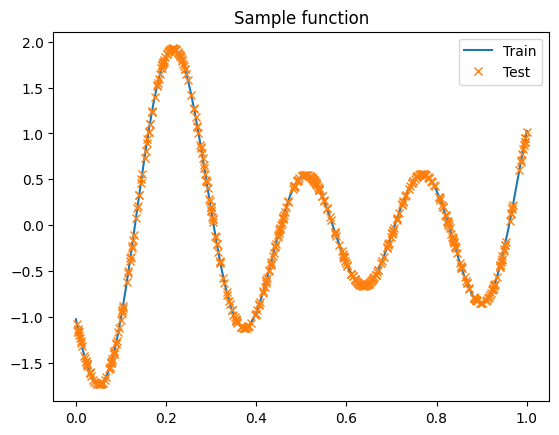

In [3]:
plt.title('Sample function')
plt.plot(x, y)
plt.plot(x_test, y_test, 'x')
plt.legend(['Train', 'Test'])
plt.show()

# Create models and train 

In [4]:
num_runs = 5
force_rerun = False

In [5]:
def save_runs(name, runs):
    filename = f'{name}.pkl'
    with open(filename, 'wb') as f:
        pickle.dump(runs, f)

def load_runs(name):
    filename = f'{name}.pkl'
    if os.path.exists(filename):
        with open(filename, 'rb') as f:
            runs = pickle.load(f)
        return runs
    else:
        return None

In [6]:
all_gn_runs = load_runs('gn-exact')

if (all_gn_runs is None) or (force_rerun is True):
    model = MLP_1D(num_layers=2,hidden_dim=80)
    lm_info = PrecondData(
        method='gn-exact', 
    )
    # This is the one run case
    # state = create_train_state(model, rng=jax.random.key(0), learning_rate=1e-2, momentum=0, optimizer='sgd')
    # state, metrics_history_gn = train_model(state, x, y, num_iterations=200000, obtain_matrices=False, 
    #                                     lm_schedule=lm_info, batch_size=100, 
    #                                         x_test=x_test, y_test=y_test, 
    #                                         save_weights=True, 
    #                                         seed=0
    #                                     )
    
    all_gn_runs = []
    for i in range(num_runs):
        state = create_train_state(model, rng=jax.random.key(i), learning_rate=1e-2, momentum=0, optimizer='sgd')
        state, metrics_history_gn = train_model(state, x, y, num_iterations=200000, obtain_matrices=False, 
                                            lm_schedule=lm_info, batch_size=100, 
                                                x_test=x_test, y_test=y_test, 
                                                save_weights=True, 
                                                seed=i
                                            )
        all_gn_runs.append((state.params, metrics_history_gn))
    save_runs('gn-exact', all_gn_runs)
else: 
    print('Loaded from save file')

Loaded from save file


In [7]:
plot_results(state, metrics_history_gn, x, y)
plt.show()


NameError: name 'state' is not defined

In [ ]:
# One run case 
# plt.title('Test and train loss in GN dynamics')
# plt.semilogy(metrics_history_gn['train_loss'], label='train_loss')
# plt.legend()
# plt.show()

plt.title('Test and Train Loss in GN Dynamics')

# Assuming all_gn_runs is a list of tuples (state, hist)
train_losses = [hist['train_loss'] for state, hist in all_gn_runs]

# Convert to a NumPy array for easier manipulation
train_losses = jnp.array(train_losses)

# Calculate mean and median
mean_train_loss = jnp.mean(train_losses, axis=0)
median_train_loss = jnp.median(train_losses, axis=0)

# Plot the mean and median loss
plt.semilogy(mean_train_loss, label='Mean Train Loss', color='blue', linestyle='--')
plt.semilogy(median_train_loss, label='Median Train Loss', color='orange')

# Optionally, plot individual runs for reference
for hist in all_gn_runs:
    plt.semilogy(hist[1]['train_loss'], color='gray', alpha=0.5)

# Plot the min and max for variability
min_train_loss = jnp.min(train_losses, axis=0)
max_train_loss = jnp.max(train_losses, axis=0)
plt.fill_between(range(len(mean_train_loss)), 
                 min_train_loss, 
                 max_train_loss, color='blue', alpha=0.5, label='Min-Max Range')

plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [ ]:
# Single run code 
# n = len(y)
# all_fft = []
# for est in metrics_history_gn['prediction']:
#     fft_err = jnp.fft.fft(y - est) / n
#     fft_err = fft_err[:n // 2]
#     fft_err = jnp.abs(fft_err)
#     all_fft.append(fft_err.flatten())
# all_fft = jnp.array(all_fft).T

# # Limit the number of frequencies to plot
# num_frequencies_to_plot = min(all_fft.shape[0], 10)  # Adjust as needed

# plt.figure(figsize=(8, 6))
# for i in range(num_frequencies_to_plot):
#     plt.semilogy(all_fft[i], label=f'Freq {i}', alpha=0.7)  # Use alpha for transparency

# plt.title('FFT of Residual')
# plt.xlabel('Training Epoch x 100')
# plt.ylabel('Residual Frequency (Magnitude)')
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
# # plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))  # Place legend outside
# plt.legend()
# plt.tight_layout()
# plt.show()

In [ ]:
n = len(y)
all_fft_runs = []

# Compute FFT errors for all runs
for params, metrics_history in all_gn_runs:
    fft_run = []
    for est in metrics_history['prediction']:
        fft_err = jnp.fft.fft(y - est) / n
        fft_err = fft_err[:n // 2]
        fft_err = jnp.abs(fft_err)
        fft_run.append(fft_err.flatten())
    all_fft_runs.append(jnp.array(fft_run).T)

# Combine FFT errors across all runs
all_fft_runs = jnp.array(all_fft_runs)  # Shape: (num_runs, num_frequencies, num_epochs)

# Compute statistics across runs
fft_max = jnp.max(all_fft_runs, axis=0)  # Shape: (num_frequencies, num_epochs)
fft_min = jnp.min(all_fft_runs, axis=0)  # Shape: (num_frequencies, num_epochs)
fft_median = jnp.median(all_fft_runs, axis=0)  # Shape: (num_frequencies, num_epochs)

# Limit the number of frequencies to plot
num_frequencies_to_plot = min(fft_max.shape[0], 10)  # Adjust as needed

plt.figure(figsize=(8, 6))
for i in range(num_frequencies_to_plot):
    # Plot median
    plt.semilogy(fft_median[i], label=f'Freq {i}', alpha=0.7)
    # Fill between min and max
    plt.fill_between(range(len(fft_median[i])), fft_min[i], fft_max[i], alpha=0.2)

plt.title('FFT of Residual')
plt.xlabel('Training Epoch x 100')
plt.ylabel('Residual Frequency (Magnitude)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))  # Place legend outside
plt.tight_layout()
plt.show()


In [ ]:
all_sgd_runs = load_runs('sgd')

if (all_sgd_runs is None) or (force_rerun is True):
    model = MLP_1D(num_layers=2,hidden_dim=80)

    all_sgd_runs = []
    for i in range(num_runs):
        state = create_train_state(model,rng=jax.random.key(i), learning_rate=1e-2, momentum=0, optimizer='sgd')
        state, metrics_history_sgd = train_model(state, x, y, num_iterations=300000, obtain_matrices=False, 
                                            lm_schedule=None, batch_size=100, 
                                                 x_test=x_test, y_test=y_test,
                                                 save_weights=True,
                                                 seed=i
                                            )
        all_sgd_runs.append((state.params, metrics_history_sgd))

    save_runs('sgd', all_sgd_runs)
else:
    print('Loaded from save file')


In [ ]:
all_sgd_runs[2][1]['train_loss'][0]

In [ ]:
plt.title('Test and Train Loss in SGD Dynamics')

train_losses = [hist['train_loss'] for state, hist in all_sgd_runs]

# Convert to a NumPy array for easier manipulation
train_losses = jnp.array(train_losses)

# Calculate mean and median
mean_train_loss = jnp.mean(train_losses, axis=0)
median_train_loss = jnp.median(train_losses, axis=0)

# Plot the mean and median loss
plt.semilogy(mean_train_loss, label='Mean Train Loss', color='blue', linestyle='--')
plt.semilogy(median_train_loss, label='Median Train Loss', color='orange')

# Optionally, plot individual runs for reference
for hist in all_sgd_runs:
    plt.semilogy(hist[1]['train_loss'], color='gray', alpha=0.5)

# Plot the min and max for variability
min_train_loss = jnp.min(train_losses, axis=0)
max_train_loss = jnp.max(train_losses, axis=0)
plt.fill_between(range(len(mean_train_loss)), 
                 min_train_loss, 
                 max_train_loss, color='blue', alpha=0.5, label='Min-Max Range')

plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [ ]:
n = len(y)
all_fft_runs = []

# Compute FFT errors for all runs
for params, metrics_history in all_sgd_runs:
    fft_run = []
    for est in metrics_history['prediction']:
        fft_err = jnp.fft.fft(y - est) / n
        fft_err = fft_err[:n // 2]
        fft_err = jnp.abs(fft_err)
        fft_run.append(fft_err.flatten())
    all_fft_runs.append(jnp.array(fft_run).T)

# Combine FFT errors across all runs
all_fft_runs = jnp.array(all_fft_runs)  # Shape: (num_runs, num_frequencies, num_epochs)

# Compute statistics across runs
fft_max = jnp.max(all_fft_runs, axis=0)  # Shape: (num_frequencies, num_epochs)
fft_min = jnp.min(all_fft_runs, axis=0)  # Shape: (num_frequencies, num_epochs)
fft_median = jnp.median(all_fft_runs, axis=0)  # Shape: (num_frequencies, num_epochs)

# Limit the number of frequencies to plot
num_frequencies_to_plot = min(fft_max.shape[0], 10)  # Adjust as needed

plt.figure(figsize=(8, 6))
for i in range(num_frequencies_to_plot):
    # Plot median
    plt.semilogy(fft_median[i], label=f'Freq {i}', alpha=0.7)
    # Fill between min and max
    plt.fill_between(range(len(fft_median[i])), fft_min[i], fft_max[i], alpha=1)

plt.title('FFT of Residual')
plt.xlabel('Training Epoch x 100')
plt.ylabel('Residual Frequency (Magnitude)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))  # Place legend outside
plt.tight_layout()
plt.show()


In [ ]:
plt.semilogx(jnp.array(metrics_history_gn['test_loss'])/ metrics_history_gn['test_loss'][0], '--', label='gn_loss')
plt.semilogx(jnp.array(metrics_history_gn['train_loss'][::100]) / metrics_history_gn['train_loss'][0], label='train_gn_loss')

plt.semilogx(jnp.array(metrics_history_sgd['test_loss'])/metrics_history_sgd['test_loss'][0], '--', label='sgd_loss')
plt.semilogx(jnp.array(metrics_history_sgd['train_loss'][::100]) / metrics_history_sgd['train_loss'][0],  label='train_sgd_loss')
plt.legend()
plt.show()


In [ ]:
all_adam_runs = load_runs('adam')

if (all_adam_runs is None) or (force_rerun is True):
    model = MLP_1D(num_layers=2,hidden_dim=80)
    
    all_adam_runs = []
    for i in range(num_runs):

        state = create_train_state(model,rng=jax.random.key(i), learning_rate=5e-5, momentum=0, optimizer='adam')
        state, metrics_history_adam = train_model(state, x, y, num_iterations=100000, obtain_matrices=False, 
                                            lm_schedule=None, batch_size=100, 
                                                 x_test=x_test, y_test=y_test, 
                                                  save_weights=True,
                                                  seed=i
                                            )
        all_adam_runs.append((state.params, metrics_history_adam))
    save_runs('adam', all_adam_runs)
else:
    print('Loaded from save file')



In [ ]:
plt.title('Test and Train Loss in Adam Dynamics')

train_losses = [hist['train_loss'] for state, hist in all_adam_runs]

# Convert to a NumPy array for easier manipulation
train_losses = jnp.array(train_losses)

# Calculate mean and median
mean_train_loss = jnp.mean(train_losses, axis=0)
median_train_loss = jnp.median(train_losses, axis=0)

# Plot the mean and median loss
plt.semilogy(mean_train_loss, label='Mean Train Loss', color='blue', linestyle='--')
plt.semilogy(median_train_loss, label='Median Train Loss', color='orange')

# Optionally, plot individual runs for reference
for hist in all_adam_runs:
    plt.semilogy(hist[1]['train_loss'], color='gray', alpha=0.5)

# Plot the min and max for variability
min_train_loss = jnp.min(train_losses, axis=0)
max_train_loss = jnp.max(train_losses, axis=0)
plt.fill_between(range(len(mean_train_loss)), 
                 min_train_loss, 
                 max_train_loss, color='blue', alpha=0.5, label='Min-Max Range')

plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [ ]:
n = len(y)
all_fft_runs = []

# Compute FFT errors for all runs
for params, metrics_history in all_adam_runs:
    fft_run = []
    for est in metrics_history['prediction']:
        fft_err = jnp.fft.fft(y - est) / n
        fft_err = fft_err[:n // 2]
        fft_err = jnp.abs(fft_err)
        fft_run.append(fft_err.flatten())
    all_fft_runs.append(jnp.array(fft_run).T)

# Combine FFT errors across all runs
all_fft_runs = jnp.array(all_fft_runs)  # Shape: (num_runs, num_frequencies, num_epochs)

# Compute statistics across runs
fft_max = jnp.max(all_fft_runs, axis=0)  # Shape: (num_frequencies, num_epochs)
fft_min = jnp.min(all_fft_runs, axis=0)  # Shape: (num_frequencies, num_epochs)
fft_median = jnp.median(all_fft_runs, axis=0)  # Shape: (num_frequencies, num_epochs)

# Limit the number of frequencies to plot
num_frequencies_to_plot = min(fft_max.shape[0], 10)  # Adjust as needed

plt.figure(figsize=(8, 6))
for i in range(num_frequencies_to_plot):
    # Plot median
    plt.semilogy(fft_median[i], label=f'Freq {i}', alpha=0.7)
    # Fill between min and max
    plt.fill_between(range(len(fft_median[i])), fft_min[i], fft_max[i], alpha=1)

plt.title('FFT of Residual')
plt.xlabel('Training Epoch x 100')
plt.ylabel('Residual Frequency (Magnitude)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))  # Place legend outside
plt.tight_layout()
plt.show()


In [ ]:
all_lm_runs = load_runs('lm')

if (all_lm_runs is None) or (force_rerun is True):
    model = MLP_1D(num_layers=2,hidden_dim=80)

    all_lm_runs = []
    for i in range(num_runs):
        lm_info = PrecondData(
            method='smw',epoch=0, lamb=1e-1,
        )
        
        state = create_train_state(model, rng=jax.random.key(i),learning_rate=1e-2, momentum=0, optimizer='sgd')
        state, metrics_history_lm = train_model(state, x, y, num_iterations=200000, obtain_matrices=False, 
                                            lm_schedule=lm_info, batch_size=100,
                                            x_test=x_test, y_test=y_test, 
                                                save_weights=True,
                                                seed=i
                                            )
        all_lm_runs.append((state.params, metrics_history_lm))

    save_runs('lm', all_lm_runs)
else:
    print('Loaded from save file')

In [ ]:
# One run case 
# plt.title('Test and train loss in GN dynamics')
# plt.semilogy(metrics_history_gn['train_loss'], label='train_loss')
# plt.legend()
# plt.show()

plt.title('Test and Train Loss in LM Dynamics')

# Assuming all_gn_runs is a list of tuples (state, hist)
train_losses = [hist['train_loss'] for state, hist in all_lm_runs]

# Convert to a NumPy array for easier manipulation
train_losses = jnp.array(train_losses)

# Calculate mean and median
mean_train_loss = jnp.mean(train_losses, axis=0)
median_train_loss = jnp.median(train_losses, axis=0)

# Plot the mean and median loss
plt.semilogy(mean_train_loss, label='Mean Train Loss', color='blue', linestyle='--')
plt.semilogy(median_train_loss, label='Median Train Loss', color='orange')

# Optionally, plot individual runs for reference
for hist in all_lm_runs:
    plt.semilogy(hist[1]['train_loss'], color='gray', alpha=0.5)

# Plot the min and max for variability
min_train_loss = jnp.min(train_losses, axis=0)
max_train_loss = jnp.max(train_losses, axis=0)
plt.fill_between(range(len(mean_train_loss)), 
                 min_train_loss, 
                 max_train_loss, color='blue', alpha=0.5, label='Min-Max Range')

plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [ ]:
n = len(y)
all_fft_runs = []

# Compute FFT errors for all runs
for params, metrics_history in all_lm_runs:
    fft_run = []
    for est in metrics_history['prediction']:
        fft_err = jnp.fft.fft(y - est) / n
        fft_err = fft_err[:n // 2]
        fft_err = jnp.abs(fft_err)
        fft_run.append(fft_err.flatten())
    all_fft_runs.append(jnp.array(fft_run).T)

# Combine FFT errors across all runs
all_fft_runs = jnp.array(all_fft_runs)  # Shape: (num_runs, num_frequencies, num_epochs)

# Compute statistics across runs
fft_max = jnp.max(all_fft_runs, axis=0)  # Shape: (num_frequencies, num_epochs)
fft_min = jnp.min(all_fft_runs, axis=0)  # Shape: (num_frequencies, num_epochs)
fft_median = jnp.median(all_fft_runs, axis=0)  # Shape: (num_frequencies, num_epochs)

# Limit the number of frequencies to plot
num_frequencies_to_plot = min(fft_max.shape[0], 10)  # Adjust as needed

plt.figure(figsize=(8, 6))
for i in range(num_frequencies_to_plot):
    # Plot median
    plt.semilogy(fft_median[i], label=f'Freq {i}', alpha=0.7)
    # Fill between min and max
    plt.fill_between(range(len(fft_median[i])), fft_min[i], fft_max[i], alpha=0.2)

plt.title('FFT of Residual')
plt.xlabel('Training Epoch x 100')
plt.ylabel('Residual Frequency (Magnitude)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))  # Place legend outside
plt.tight_layout()
plt.show()


In [ ]:
all_lm_5_runs = load_runs('lm_5')

if (all_lm_5_runs is None) or (force_rerun is True): 
    model = MLP_1D(num_layers=2,hidden_dim=80)
    lm_info = PrecondData(
        method='smw',epoch=0, lamb=5e-1,
    )

    all_lm_5_runs = []
    for i in range(num_runs):
        
        state = create_train_state(model, rng=jax.random.key(i), learning_rate=1e-2, momentum=0, optimizer='sgd')
        state, metrics_history_lm_5 = train_model(state, x, y, num_iterations=200000, obtain_matrices=False, 
                                            lm_schedule=lm_info, batch_size=100,
                                            x_test=x_test, y_test=y_test, 
                                                  save_weights=True, 
                                                  seed=i
                                            )

        all_lm_5_runs.append((state.params, metrics_history_lm_5))

    save_runs('lm_5', all_lm_5_runs)
else: 
    print('Loaded form save file')


In [ ]:
# One run case 
# plt.title('Test and train loss in GN dynamics')
# plt.semilogy(metrics_history_gn['train_loss'], label='train_loss')
# plt.legend()
# plt.show()

plt.title('Test and Train Loss in LM Dynamics')

# Assuming all_gn_runs is a list of tuples (state, hist)
train_losses = [hist['train_loss'] for state, hist in all_lm_5_runs]

# Convert to a NumPy array for easier manipulation
train_losses = jnp.array(train_losses)

# Calculate mean and median
mean_train_loss = jnp.mean(train_losses, axis=0)
median_train_loss = jnp.median(train_losses, axis=0)

# Plot the mean and median loss
plt.semilogy(mean_train_loss, label='Mean Train Loss', color='blue', linestyle='--')
plt.semilogy(median_train_loss, label='Median Train Loss', color='orange')

# Optionally, plot individual runs for reference
for hist in all_lm_5_runs:
    plt.semilogy(hist[1]['train_loss'], color='gray', alpha=0.5)

# Plot the min and max for variability
min_train_loss = jnp.min(train_losses, axis=0)
max_train_loss = jnp.max(train_losses, axis=0)
plt.fill_between(range(len(mean_train_loss)), 
                 min_train_loss, 
                 max_train_loss, color='blue', alpha=0.5, label='Min-Max Range')

plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [ ]:
plot_results(state, metrics_history_lm_5, x, y)
plt.show()


In [ ]:
n = len(y)
all_fft_runs = []

# Compute FFT errors for all runs
for params, metrics_history in all_lm_5_runs:
    fft_run = []
    for est in metrics_history['prediction']:
        fft_err = jnp.fft.fft(y - est) / n
        fft_err = fft_err[:n // 2]
        fft_err = jnp.abs(fft_err)
        fft_run.append(fft_err.flatten())
    all_fft_runs.append(jnp.array(fft_run).T)

# Combine FFT errors across all runs
all_fft_runs = jnp.array(all_fft_runs)  # Shape: (num_runs, num_frequencies, num_epochs)

# Compute statistics across runs
fft_max = jnp.max(all_fft_runs, axis=0)  # Shape: (num_frequencies, num_epochs)
fft_min = jnp.min(all_fft_runs, axis=0)  # Shape: (num_frequencies, num_epochs)
fft_median = jnp.median(all_fft_runs, axis=0)  # Shape: (num_frequencies, num_epochs)

# Limit the number of frequencies to plot
num_frequencies_to_plot = min(fft_max.shape[0], 10)  # Adjust as needed

plt.figure(figsize=(8, 6))
for i in range(num_frequencies_to_plot):
    # Plot median
    plt.semilogy(fft_median[i], label=f'Freq {i}', alpha=0.7)
    # Fill between min and max
    plt.fill_between(range(len(fft_median[i])), fft_min[i], fft_max[i], alpha=0.2)

plt.title('FFT of Residual')
plt.xlabel('Training Epoch x 100')
plt.ylabel('Residual Frequency (Magnitude)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))  # Place legend outside
plt.tight_layout()
plt.show()


In [ ]:
all_lm_01_runs = load_runs('lm_01')

if (all_lm_01_runs is None) or (force_rerun is True): 
    
    model = MLP_1D(num_layers=2,hidden_dim=80)
    lm_info = PrecondData(
        method='smw',epoch=0, lamb=1e-2,
    )

    all_lm_01_runs = []
    for i in range(num_runs):
        state = create_train_state(model, rng=jax.random.key(i), learning_rate=1e-2, momentum=0, optimizer='sgd')
        state, metrics_history_lm_01 = train_model(state, x, y, num_iterations=200000, obtain_matrices=False, 
                                            lm_schedule=lm_info, batch_size=100,
                                            x_test=x_test, y_test=y_test, 
                                                   save_weights=True, 
                                                    seed=i
                                            )
        all_lm_01_runs.append((state.params, metrics_history_lm_01))
    save_runs('lm_01', all_lm_01_runs)
else: 
    print('Loaded from save file')


In [ ]:
# One run case 
# plt.title('Test and train loss in GN dynamics')
# plt.semilogy(metrics_history_gn['train_loss'], label='train_loss')
# plt.legend()
# plt.show()

plt.title('Test and Train Loss in LM Dynamics')

# Assuming all_gn_runs is a list of tuples (state, hist)
train_losses = [hist['train_loss'] for state, hist in all_lm_01_runs]

# Convert to a NumPy array for easier manipulation
train_losses = jnp.array(train_losses)

# Calculate mean and median
mean_train_loss = jnp.mean(train_losses, axis=0)
median_train_loss = jnp.median(train_losses, axis=0)

# Plot the mean and median loss
plt.semilogy(mean_train_loss, label='Mean Train Loss', color='blue', linestyle='--')
plt.semilogy(median_train_loss, label='Median Train Loss', color='orange')

# Optionally, plot individual runs for reference
for hist in all_lm_01_runs:
    plt.semilogy(hist[1]['train_loss'], color='gray', alpha=0.5)

# Plot the min and max for variability
min_train_loss = jnp.min(train_losses, axis=0)
max_train_loss = jnp.max(train_losses, axis=0)
plt.fill_between(range(len(mean_train_loss)), 
                 min_train_loss, 
                 max_train_loss, color='blue', alpha=0.5, label='Min-Max Range')

plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [ ]:
n = len(y)
all_fft_runs = []

# Compute FFT errors for all runs
for params, metrics_history in all_lm_01_runs:
    fft_run = []
    for est in metrics_history['prediction']:
        fft_err = jnp.fft.fft(y - est) / n
        fft_err = fft_err[:n // 2]
        fft_err = jnp.abs(fft_err)
        fft_run.append(fft_err.flatten())
    all_fft_runs.append(jnp.array(fft_run).T)

# Combine FFT errors across all runs
all_fft_runs = jnp.array(all_fft_runs)  # Shape: (num_runs, num_frequencies, num_epochs)

# Compute statistics across runs
fft_max = jnp.max(all_fft_runs, axis=0)  # Shape: (num_frequencies, num_epochs)
fft_min = jnp.min(all_fft_runs, axis=0)  # Shape: (num_frequencies, num_epochs)
fft_median = jnp.median(all_fft_runs, axis=0)  # Shape: (num_frequencies, num_epochs)

# Limit the number of frequencies to plot
num_frequencies_to_plot = min(fft_max.shape[0], 10)  # Adjust as needed

plt.figure(figsize=(8, 6))
for i in range(num_frequencies_to_plot):
    # Plot median
    plt.semilogy(fft_median[i], label=f'Freq {i}', alpha=0.7)
    # Fill between min and max
    plt.fill_between(range(len(fft_median[i])), fft_min[i], fft_max[i], alpha=0.2)

plt.title('FFT of Residual')
plt.xlabel('Training Epoch x 100')
plt.ylabel('Residual Frequency (Magnitude)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))  # Place legend outside
plt.tight_layout()
plt.show()


In [ ]:
# Create subfigures
fig, subfigs = plt.subplots(1, 4, figsize=(20, 5))  # 1 row, 4 columns

metrics_histories = [metrics_history_sgd, metrics_history_lm_5, metrics_history_lm, metrics_history_gn]
names = ['SGD', 'LM $\mu=0.5$', 'LM $\mu=0.1$', 'GN']
for idx, metrics_history in enumerate(metrics_histories):
    n = len(y)
    all_fft = []
    
    for est in metrics_history['prediction']:
        fft_err = jnp.fft.fft(y - est) / n
        fft_err = fft_err[:n // 2]
        fft_err = jnp.abs(fft_err)
        all_fft.append(fft_err.flatten())
    
    all_fft = jnp.array(all_fft).T
    print(all_fft.shape)
    
    # Limit the number of frequencies to plot
    num_frequencies_to_plot = min(all_fft.shape[0], 10)  # Adjust as needed

    for i in range(num_frequencies_to_plot):
        subfigs[idx].semilogy(all_fft[i], label=f'Freq {i}', alpha=1)  # Use alpha for transparency

    subfigs[idx].set_title(f'{names[idx]}')
    subfigs[idx].set_xlabel('Training Epoch x 100')
    if idx == 0:
        subfigs[idx].set_ylabel('Residual Frequency (Magnitude)')
    subfigs[idx].grid(True, which='both', linestyle='--', linewidth=0.5)
    subfigs[idx].set_ylim(1e-7, 3e-2)
    # subfigs[idx].legend(loc='upper right', bbox_to_anchor=(1.2, 1))  # Place legend outside

plt.tight_layout()
plt.savefig('ex_1.png')
plt.show()

In [ ]:
# Create subfigures
fig, subfigs = plt.subplots(1, 4, figsize=(20, 5))  # 1 row, 4 columns

# Define the data and names
all_runs = [all_sgd_runs, all_lm_5_runs, all_lm_runs, all_gn_runs]
names = ['SGD', 'LM $\mu=0.5$', 'LM $\mu=0.1$', 'GN']

for idx, runs in enumerate(all_runs):
    n = len(y)
    all_fft_runs = []
    
    # Compute FFT errors for all runs
    for _, metrics_history in runs:
        fft_run = []
        for est in metrics_history['prediction']:
            fft_err = jnp.fft.fft(y - est) / n
            fft_err = fft_err[:n // 2]
            fft_err = jnp.abs(fft_err)
            fft_run.append(fft_err.flatten())
        all_fft_runs.append(jnp.array(fft_run).T)
    
    # Combine FFT errors across all runs
    all_fft_runs = jnp.array(all_fft_runs)  # Shape: (num_runs, num_frequencies, num_epochs)
    
    # Compute statistics across runs
    fft_max = jnp.max(all_fft_runs, axis=0)  # Shape: (num_frequencies, num_epochs)
    fft_min = jnp.min(all_fft_runs, axis=0)  # Shape: (num_frequencies, num_epochs)
    fft_median = jnp.median(all_fft_runs, axis=0)  # Shape: (num_frequencies, num_epochs)

    # Limit the number of frequencies to plot
    num_frequencies_to_plot = min(fft_max.shape[0], 10)  # Adjust as needed

    for i in range(num_frequencies_to_plot):
        subfigs[idx].semilogy(fft_median[i], label=f'Freq {i} Median', alpha=1)
        subfigs[idx].fill_between(range(len(fft_median[i])), fft_min[i], fft_max[i], alpha=0.4)

    subfigs[idx].set_title(f'{names[idx]}')
    subfigs[idx].set_xlabel('Training Epoch x 100')
    if idx == 0:
        subfigs[idx].set_ylabel('Residual Frequency (Magnitude)')
    subfigs[idx].grid(True, which='both', linestyle='--', linewidth=0.5)
    subfigs[idx].set_ylim(1e-7, 3e-2)
    # subfigs[idx].legend(loc='upper right', bbox_to_anchor=(1.2, 1))  # Place legend outside
    
plt.tight_layout()
plt.savefig('ex_1_min_max_median.png')
plt.show()

In [ ]:
plt.semilogy(metrics_history_gn['test_loss'], label='GN')
plt.semilogy(metrics_history_sgd['test_loss'],  label='SGD')
plt.semilogy(metrics_history_lm_5['test_loss'], label='LM $\mu=0.5$')
plt.semilogy(metrics_history_lm['test_loss'], label='LM $\mu=0.1$')

plt.semilogy(metrics_history_gn['train_loss'][::100], '.-', label='GN', alpha=.5)
plt.semilogy(metrics_history_sgd['train_loss'][::100], '.-', label='SGD', alpha=.5)
plt.semilogy(metrics_history_lm_5['train_loss'][::100], '.-',label='LM $\mu=0.5$', alpha=.5)
plt.semilogy(metrics_history_lm['train_loss'][::100], '.-', label='LM $\mu=0.1$', alpha=.5)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlabel('Training Epoch x 100')
plt.ylabel('Test Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.savefig('test_ex_1.png')
plt.show()


# Let's look at the error... 

I want to train for a really long time using Adam with LR plateau weight decay; it's a bit difficult to be flexible in the original training code. 

In [10]:
import optax
from optax import tree_utils as otu
import orbax.checkpoint
from flax.training import orbax_utils

In [28]:
lr = 5e-3
opt = optax.chain(
    optax.adam(lr),
    optax.contrib.reduce_on_plateau(
        patience=50,
        cooldown=0,
        factor=0.5,
        rtol=1e-4,
        accumulation_size=1,
    ),
)

rng = jax.random.PRNGKey(0)
model = MLP_1D(num_layers=2,hidden_dim=80)
model_params = model.init(rng, jnp.ones([1]))
opt_state = opt.init(model_params)
num_iterations = 500000
batch_size=100

@jax.jit
def loss_calc(params, x, y):
    out = model.apply(params, x)
    loss = optax.squared_error(out, y).mean()
    return loss
        
@partial(jax.jit)
def train_step(params, opt_state, x, y):
    loss, grad = jax.value_and_grad(loss_calc)(params, x, y)
    updates, opt_state = opt.update(grad, opt_state, params, value=loss)
    params = optax.apply_updates(params, updates)    
    return params, opt_state, loss

metrics_history = {
    'train_loss': [],
    'scale': [],
}

rng_key = jax.random.PRNGKey(0)
for epoch in tqdm(range(num_iterations), leave=True):
    # Jax randomness kinda sucks; but this ensures that each epoch the batches are diff
    rng_key, subkey = jax.random.split(rng_key)

    epoch_loss = 0
    num_batches = 0

    for x_batch, y_batch in batch_data(x, y, batch_size, subkey):
        model_params, opt_state, loss = train_step(model_params, opt_state, x_batch, y_batch)
        epoch_loss += loss
        num_batches += 1

    # Compute the average loss for the epoch
    avg_loss = epoch_loss / num_batches
    metrics_history['train_loss'].append(avg_loss)
    metrics_history['scale'].append(otu.tree_get(opt_state, "scale"))

# ckpt = {'model': model_params}

# current_directory = os.getcwd()
# subdirectory_path = os.path.join(current_directory, 'ckpts')

# orbax_checkpointer = orbax.checkpoint.PyTreeCheckpointer()
# save_args = orbax_utils.save_args_from_target(ckpt)
# orbax_checkpointer.save(subdirectory_path, ckpt, save_args=save_args, force=True)

  1%|▌                                               | 5277/500000 [00:15<24:14, 340.20it/s]


KeyboardInterrupt: 

In [ ]:
plt.semilogy(metrics_history['scale'])
plt.semilogy(metrics_history['train_loss'])


In [25]:
# Define the path to the checkpoint
current_directory = os.getcwd()
subdirectory_path = os.path.join(current_directory, 'ckpts')
checkpoint_path = os.path.join(subdirectory_path, 'your_checkpoint_file_name')  # Replace with your actual checkpoint file name

# Create a checkpointer instance
orbax_checkpointer = orbax.checkpoint.PyTreeCheckpointer()

# Restore the model parameters from the checkpoint
model_params = orbax_checkpointer.restore(subdirectory_path)

# Use this as error 
true_param = model_params['model']

/home/sjiang/precond-gd/.venv/lib/python3.13/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1250: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


In [99]:
errors_gn, errors_sgd, errors_adam = [], [], []
for i in range(len(metrics_history_gn['weights'])):
    squared_diffs = jax.tree_map(lambda x, y: jnp.sum((x - y) ** 2), true_param, 
                                 metrics_history_gn['weights'][i])
    errors_gn.append(jnp.sqrt(jax.tree.reduce(jnp.add, squared_diffs)))

    squared_diffs = jax.tree_map(lambda x, y: jnp.sum((x - y) ** 2), true_param, 
                                 metrics_history_sgd['weights'][i])
    errors_sgd.append(jnp.sqrt(jax.tree.reduce(jnp.add, squared_diffs)))
    
    squared_diffs = jax.tree_map(lambda x, y: jnp.sum((x - y) ** 2), true_param, 
                                 metrics_history_adam['weights'][i])
    errors_adam.append(jnp.sqrt(jax.tree.reduce(jnp.add, squared_diffs)))


Text(0, 0.5, 'L2 error')

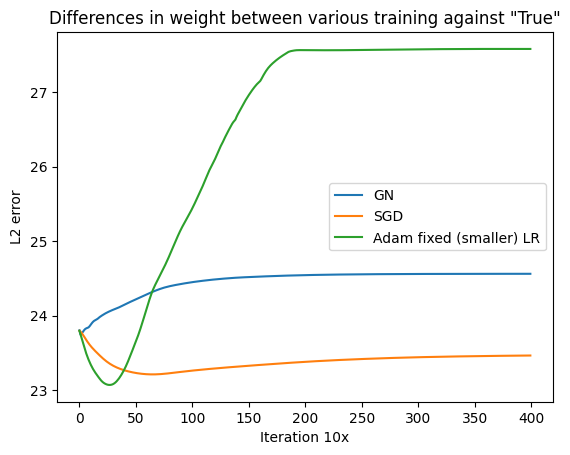

In [100]:
plt.plot(errors_gn)
plt.plot(errors_sgd)
plt.plot(errors_adam)
plt.legend(['GN', 'SGD', 'Adam fixed (smaller) LR'])
plt.title('Differences in weight between various training against "True"')
plt.xlabel('Iteration 10x')
plt.ylabel('L2 error')

In [97]:
squared_diffs = jax.tree_map(lambda x, y: jnp.sum((x - y) ** 2), 
                             metrics_history_sgd['weights'][0], 
                             metrics_history_gn['weights'][0])
print(squared_diffs)

squared_diffs = jax.tree_map(lambda x, y: jnp.sum((x - y) ** 2), 
                             metrics_history_sgd['weights'][0], 
                             metrics_history_adam['weights'][0])
print(squared_diffs)

squared_diffs = jax.tree_map(lambda x, y: jnp.sum((x - y) ** 2), 
                             metrics_history_gn['weights'][0], 
                             metrics_history_adam['weights'][0])
print(squared_diffs)

{'params': {'Dense_0': {'bias': Array(0.00248809, dtype=float32), 'kernel': Array(0.0002978, dtype=float32)}, 'Dense_1': {'bias': Array(0.00051457, dtype=float32), 'kernel': Array(0.00973903, dtype=float32)}, 'Dense_2': {'bias': Array(0.00023689, dtype=float32), 'kernel': Array(0.00218429, dtype=float32)}}}
{'params': {'Dense_0': {'bias': Array(3.907211e-06, dtype=float32), 'kernel': Array(2.513477e-07, dtype=float32)}, 'Dense_1': {'bias': Array(2.952661e-06, dtype=float32), 'kernel': Array(1.745499e-05, dtype=float32)}, 'Dense_2': {'bias': Array(6.156446e-06, dtype=float32), 'kernel': Array(3.4969205e-05, dtype=float32)}}}
{'params': {'Dense_0': {'bias': Array(0.00246468, dtype=float32), 'kernel': Array(0.00030502, dtype=float32)}, 'Dense_1': {'bias': Array(0.00053018, dtype=float32), 'kernel': Array(0.00973358, dtype=float32)}, 'Dense_2': {'bias': Array(0.00031942, dtype=float32), 'kernel': Array(0.00208111, dtype=float32)}}}
